# Sydney Housing Price Prediction and Decision Support System
# Machine Learning Mini Project — 8.1 Distinction Task

### Student Name: Miss P K Didulangana Fernando
### Student ID: S226663385
### Module: Machine Learning
### Assessment: 8.1 Distinction Task — Machine Learning Mini Project



## Part 1: Problem Definition and Data Collection

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/DiduFernando/Sydney-Housing-Price-Prediction/main/data/raw/sydney_housing_raw.csv"

df = pd.read_csv(url)

df.head()

,property_id,property_address,suburb,postcode,property_type,sale_price_aud,bedrooms,bathrooms,parking,listed_area_m2,...,missing_feature_count,source_page,source_url,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,verification_status
0,M001,"3/66 Osborne Road, Manly, NSW 2095",Manly,2095,Apartment,1650000,2,1.0,1.0,87.0,...,0,Manly sold listings page 1,"https://www.realestate.com.au/sold/in-manly,%2...",NaN,NaN,NaN,NaN,NaN,NaN,Verified
1,M002,"4/3 Cliff Street, Manly, NSW 2095",Manly,2095,Apartment,840000,1,1.0,NaN,61.0,...,1,Manly sold listings page 1,"https://www.realestate.com.au/sold/in-manly,%2...",NaN,NaN,NaN,NaN,NaN,NaN,Verified
2,M003,"2/115-117 Sydney Road, Manly, NSW 2095",Manly,2095,Unit,2125550,2,1.0,1.0,183.0,...,0,Manly sold listings page 1,"https://www.realestate.com.au/sold/in-manly,%2...",NaN,NaN,NaN,NaN,NaN,NaN,Verified
3,M004,"35 Smith Street, Manly, NSW 2095",Manly,2095,House,3500000,3,2.0,NaN,NaN,...,2,Manly sold listings page 1,"https://www.realestate.com.au/sold/in-manly,%2...",NaN,NaN,NaN,NaN,NaN,NaN,Verified
4,M005,"5/34 Pacific Street, Manly, NSW 2095",Manly,2095,Apartment,1350000,2,1.0,NaN,NaN,...,2,Manly sold listings page 1,"https://www.realestate.com.au/sold/in-manly,%2...",NaN,NaN,NaN,NaN,NaN,NaN,Verified


In [2]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (100, 23)

Column names:
['property_id', 'property_address', 'suburb', 'postcode', 'property_type', 'sale_price_aud', 'bedrooms', 'bathrooms', 'parking', 'listed_area_m2', 'sale_date', 'sale_year', 'sale_month', 'missing_feature_count', 'source_page', 'source_url', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'verification_status']


In [3]:
# Check the suspicious unnamed columns

unnamed_cols = [col for col in df.columns if col.startswith("Unnamed:")]

print("Unnamed columns:")
print(unnamed_cols)

print("\nNon-empty values in each unnamed column:")
for col in unnamed_cols:
    print(f"{col}: {df[col].notna().sum()} non-empty values")

Unnamed columns:
['Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21']

Non-empty values in each unnamed column:
Unnamed: 16: 0 non-empty values
Unnamed: 17: 0 non-empty values
Unnamed: 18: 0 non-empty values
Unnamed: 19: 0 non-empty values
Unnamed: 20: 0 non-empty values
Unnamed: 21: 0 non-empty values


In [4]:
# Remove completely empty "Unnamed" columns
df = df.drop(columns=unnamed_cols)

print("Dataset shape after removing empty columns:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

Dataset shape after removing empty columns: (100, 17)

Remaining columns:
['property_id', 'property_address', 'suburb', 'postcode', 'property_type', 'sale_price_aud', 'bedrooms', 'bathrooms', 'parking', 'listed_area_m2', 'sale_date', 'sale_year', 'sale_month', 'missing_feature_count', 'source_page', 'source_url', 'verification_status']


In [5]:
# Check the number of properties from each suburb

suburb_counts = df["suburb"].value_counts()

print("Number of properties by suburb:")
print(suburb_counts)

Number of properties by suburb:
suburb
Manly         34
Parramatta    33
Liverpool     33
Name: count, dtype: int64


In [6]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_id            100 non-null    object 
 1   property_address       100 non-null    object 
 2   suburb                 100 non-null    object 
 3   postcode               100 non-null    int64  
 4   property_type          100 non-null    object 
 5   sale_price_aud         100 non-null    int64  
 6   bedrooms               100 non-null    int64  
 7   bathrooms              99 non-null     float64
 8   parking                90 non-null     float64
 9   listed_area_m2         52 non-null     float64
 10  sale_date              100 non-null    object 
 11  sale_year              100 non-null    int64  
 12  sale_month             100 non-null    int64  
 13  missing_feature_count  100 non-null    int64  
 14  source_page            100 non-null    object 
 15  source_

In [7]:
# Check missing values in every column

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage
property_id,0,0.0
property_address,0,0.0
suburb,0,0.0
postcode,0,0.0
property_type,0,0.0
sale_price_aud,0,0.0
bedrooms,0,0.0
bathrooms,1,1.0
parking,10,10.0
listed_area_m2,48,48.0


In [8]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
# Summary statistics for numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
postcode,100.0,2.137900e+03,3.200521e+01,2095.0,2095.00,2150.0,2170.00,2170.0
sale_price_aud,100.0,1.328486e+06,1.455999e+06,255000.0,564750.00,758500.0,1383750.00,9000000.0
bedrooms,100.0,2.180000e+00,7.962031e-01,1.0,2.00,2.0,3.00,6.0
bathrooms,99.0,1.525253e+00,5.218381e-01,1.0,1.00,2.0,2.00,3.0
parking,90.0,1.166667e+00,3.747658e-01,1.0,1.00,1.0,1.00,2.0
listed_area_m2,52.0,1.576058e+02,1.387827e+02,41.0,86.75,112.0,166.50,701.9
sale_year,100.0,2.025750e+03,4.351941e-01,2025.0,2025.75,2026.0,2026.00,2026.0
sale_month,100.0,8.250000e+00,1.313296e+00,6.0,7.00,8.0,9.25,10.0
missing_feature_count,100.0,5.800000e-01,6.060303e-01,0.0,0.00,1.0,1.00,2.0


In [10]:
# Check verification status of all records

print("Verification status:")
print(df["verification_status"].value_counts())

Verification status:
verification_status
Verified    100
Name: count, dtype: int64


In [11]:
# Check the types of properties in the dataset

print("Property types:")
print(df["property_type"].value_counts())

Property types:
property_type
Apartment    60
Unit         22
House        10
Townhouse     6
Studio        2
Name: count, dtype: int64


In [12]:
# Check for potentially invalid numerical values

print("Bedrooms <= 0:", (df["bedrooms"] <= 0).sum())
print("Bathrooms <= 0:", (df["bathrooms"] <= 0).sum())
print("Parking < 0:", (df["parking"] < 0).sum())
print("Listed area <= 0:", (df["listed_area_m2"] <= 0).sum())
print("Sale price <= 0:", (df["sale_price_aud"] <= 0).sum())

Bedrooms <= 0: 0
Bathrooms <= 0: 0
Parking < 0: 0
Listed area <= 0: 0
Sale price <= 0: 0


In [13]:
# Convert sale_date from text to datetime format

df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")

print("Sale date data type:", df["sale_date"].dtype)
print("Invalid/missing dates after conversion:", df["sale_date"].isna().sum())

Sale date data type: datetime64[ns]
Invalid/missing dates after conversion: 0


In [14]:
# Check the time period covered by the dataset

print("Earliest sale date:", df["sale_date"].min().date())
print("Latest sale date:", df["sale_date"].max().date())

print("\nProperties by sale year:")
print(df["sale_year"].value_counts().sort_index())

Earliest sale date: 2025-10-11
Latest sale date: 2026-09-17

Properties by sale year:
sale_year
2025    25
2026    75
Name: count, dtype: int64


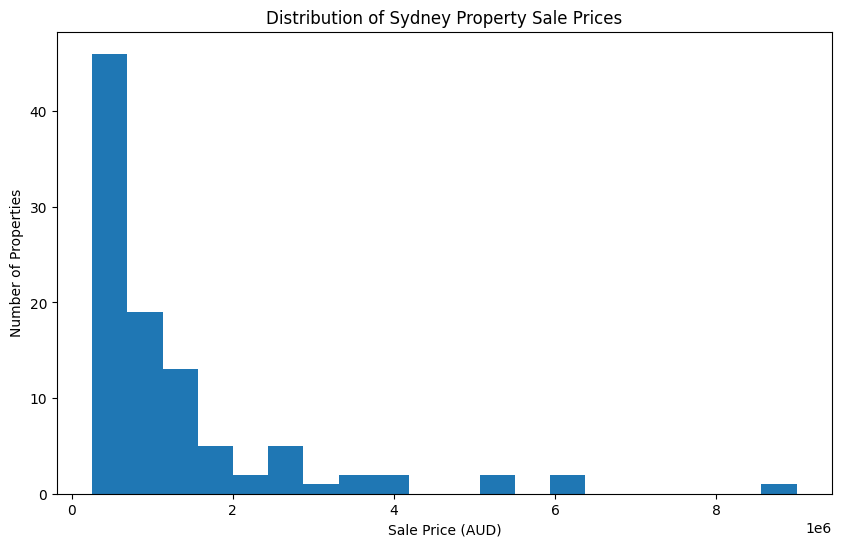

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["sale_price_aud"], bins=20)

plt.title("Distribution of Sydney Property Sale Prices")
plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Properties")

plt.show()

<Figure size 1000x600 with 0 Axes>

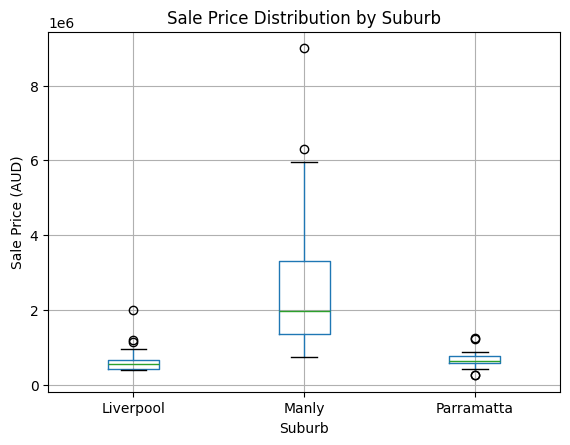

In [16]:
plt.figure(figsize=(10, 6))

df.boxplot(column="sale_price_aud", by="suburb")

plt.title("Sale Price Distribution by Suburb")
plt.suptitle("")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")

plt.show()

In [17]:
suburb_price_summary = df.groupby("suburb")["sale_price_aud"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

suburb_price_summary

,count,mean,median,min,max
suburb,,,,,
Liverpool,33,646272.73,550000.0,385000,2000000
Manly,34,2629869.12,1962500.0,747000,9000000
Parramatta,33,669878.79,650000.0,255000,1250000


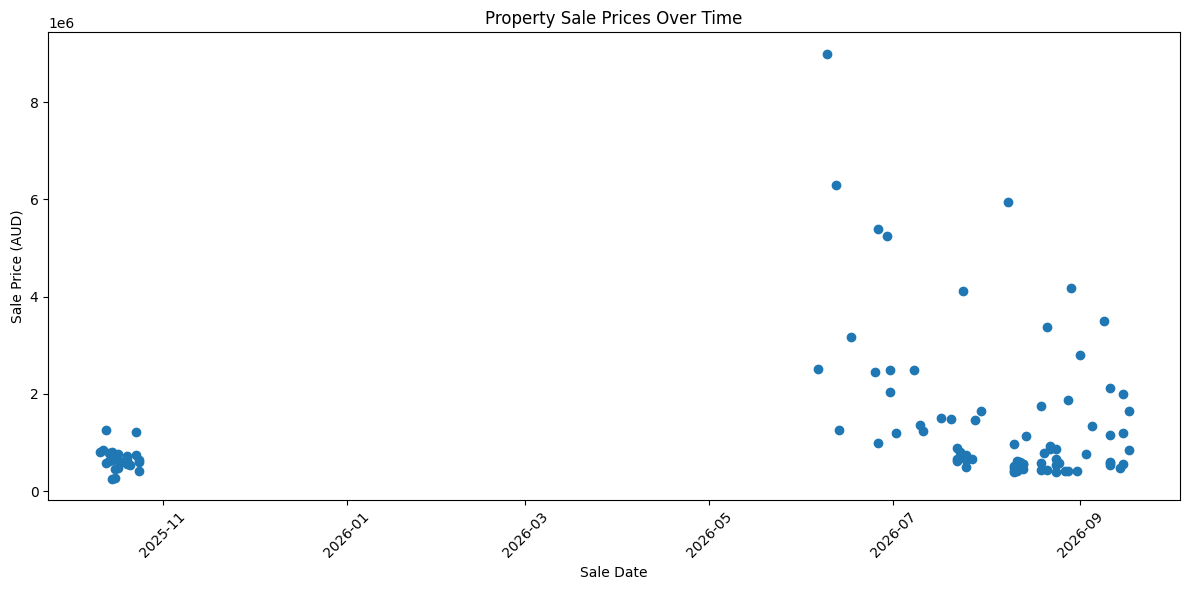

In [18]:
plt.figure(figsize=(12, 6))

plt.scatter(
    df["sale_date"],
    df["sale_price_aud"]
)

plt.title("Property Sale Prices Over Time")
plt.xlabel("Sale Date")
plt.ylabel("Sale Price (AUD)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

<Figure size 1000x600 with 0 Axes>

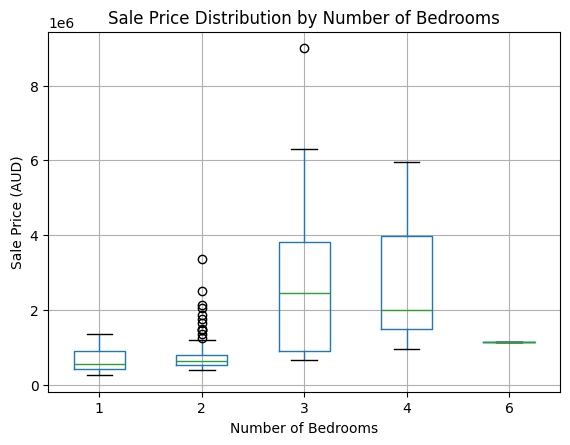

In [19]:
plt.figure(figsize=(10, 6))

df.boxplot(column="sale_price_aud", by="bedrooms")

plt.title("Sale Price Distribution by Number of Bedrooms")
plt.suptitle("")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Sale Price (AUD)")

plt.show()

In [20]:
suburb_price_summary = df.groupby("suburb")["sale_price_aud"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

suburb_price_summary

,count,mean,median,min,max
suburb,,,,,
Liverpool,33,646272.73,550000.0,385000,2000000
Manly,34,2629869.12,1962500.0,747000,9000000
Parramatta,33,669878.79,650000.0,255000,1250000


In [21]:
# Identify the highest-priced properties

top_properties = df.sort_values(
    "sale_price_aud",
    ascending=False
)[[
    "property_address",
    "suburb",
    "property_type",
    "sale_price_aud",
    "bedrooms",
    "bathrooms",
    "parking",
    "listed_area_m2",
    "sale_date"
]]

top_properties.head(10)

,property_address,suburb,property_type,sale_price_aud,bedrooms,bathrooms,parking,listed_area_m2,sale_date
32,"69 Stuart Street, Manly, NSW 2095",Manly,House,9000000,3,1.0,2.0,277.4,2026-06-09
31,"5/19a Addison Road, Manly, NSW 2095",Manly,Townhouse,6300000,3,2.0,2.0,NaN,2026-06-12
12,"31 Alexander Street, Manly, NSW 2095",Manly,House,5950000,4,2.0,NaN,NaN,2026-08-08
26,"21/140 Addison Road, Manly, NSW 2095",Manly,Apartment,5385000,3,2.0,2.0,173.0,2026-06-26
25,"32/20 Bonner Avenue, Manly, NSW 2095",Manly,Apartment,5250000,3,2.0,1.0,NaN,2026-06-29
6,"25 Malvern Avenue, Manly, NSW 2095",Manly,House,4175000,3,1.0,2.0,348.0,2026-08-29
15,"127 Pittwater Road, Manly, NSW 2095",Manly,House,4115000,3,2.0,1.0,278.0,2026-07-24
3,"35 Smith Street, Manly, NSW 2095",Manly,House,3500000,3,2.0,NaN,NaN,2026-09-09
8,"23/140 Addison Road, Manly, NSW 2095",Manly,Apartment,3370000,2,1.0,1.0,114.8,2026-08-21
29,"13/49 Osborne Road, Manly, NSW 2095",Manly,Apartment,3175000,3,2.0,1.0,126.0,2026-06-17


In [22]:
# Identify the lowest-priced properties

bottom_properties = df.sort_values(
    "sale_price_aud",
    ascending=True
)[[
    "property_address",
    "suburb",
    "property_type",
    "sale_price_aud",
    "bedrooms",
    "bathrooms",
    "parking",
    "listed_area_m2",
    "sale_date"
]]

bottom_properties.head(10)

,property_address,suburb,property_type,sale_price_aud,bedrooms,bathrooms,parking,listed_area_m2,sale_date
52,"108/22-32 Great Western Highway, Parramatta, N...",Parramatta,Studio,255000,1,1.0,NaN,41.0,2025-10-15
49,"180/22 Great Western Highway, Parramatta, NSW ...",Parramatta,Studio,270000,1,1.0,NaN,NaN,2025-10-16
99,"32/17-19 Speed Street, Liverpool, NSW 2170",Liverpool,Apartment,385000,2,1.0,1.0,79.0,2026-08-10
83,"2/30 Speed Street, Liverpool, NSW 2170",Liverpool,Apartment,385000,2,1.0,1.0,NaN,2026-08-24
77,"42/87-91 Campbell Street, Liverpool, NSW 2170",Liverpool,Apartment,410000,1,1.0,1.0,NaN,2026-08-28
94,"1/58-60 Copeland Street, Liverpool, NSW 2170",Liverpool,Apartment,412000,2,1.0,1.0,NaN,2026-08-11
76,"308/6B Atkinson Street, Liverpool, NSW 2170",Liverpool,Apartment,412000,1,1.0,1.0,84.0,2026-08-31
36,"4/29C Great Western Highway, Parramatta, NSW 2150",Parramatta,Unit,420000,2,1.0,1.0,NaN,2025-10-24
98,"8/22 Nagle Street, Liverpool, NSW 2170",Liverpool,Apartment,420000,2,1.0,1.0,77.0,2026-08-10
78,"9/53 Goulburn Street, Liverpool, NSW 2170",Liverpool,Unit,423000,2,1.0,1.0,NaN,2026-08-27


In [23]:
# Compare sale prices across property types

property_type_summary = df.groupby("property_type")["sale_price_aud"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

property_type_summary

,count,mean,median,min,max
property_type,,,,,
Apartment,60,1157183.33,668500.0,385000,5385000
House,10,3289500.00,2750000.0,870000,9000000
Studio,2,262500.00,262500.0,255000,270000
Townhouse,6,1897000.00,1093500.0,770000,6300000
Unit,22,846161.36,605000.0,420000,2500000


In [24]:
# Examine the number of sales and average price by month

monthly_summary = df.groupby(
    ["sale_year", "sale_month"]
)["sale_price_aud"].agg(
    ["count", "mean", "median"]
).round(2)

monthly_summary

count        mean     median
sale_year sale_month                              
2025      10             25   663480.00   640000.0
2026      6              11  3714818.18  2510000.0
          7              18  1264777.78  1040000.0
          8              31  1048935.48   570000.0
          9              15  1341036.67  1150000.0

In [25]:
# Examine the relationship between bedrooms and sale price

bedroom_summary = df.groupby("bedrooms")["sale_price_aud"].agg(
    ["count", "mean", "median"]
).round(2)

bedroom_summary

,count,mean,median
bedrooms,,,
1,15,692733.33,568000.0
2,58,864492.24,630000.0
3,23,2706739.13,2450000.0
4,3,2970666.67,2000000.0
6,1,1150000.00,1150000.0


In [26]:
# Examine the relationship between bathrooms and sale price

bathroom_summary = df.groupby("bathrooms")["sale_price_aud"].agg(
    ["count", "mean", "median"]
).round(2)

bathroom_summary

,count,mean,median
bathrooms,,,
1.0,48,1123615.62,663500.0
2.0,50,1544120.00,795000.0
3.0,1,962000.00,962000.0


In [27]:
# Examine the relationship between parking spaces and sale price

parking_summary = df.groupby("parking")["sale_price_aud"].agg(
    ["count", "mean", "median"]
).round(2)

parking_summary

,count,mean,median
parking,,,
1.0,75,1039460.67,650000.0
2.0,15,2501800.00,1225000.0


In [28]:
# Examine correlations between numerical variables

correlation_matrix = df[
    [
        "sale_price_aud",
        "bedrooms",
        "bathrooms",
        "parking",
        "listed_area_m2",
        "sale_year",
        "sale_month"
    ]
].corr()

correlation_matrix.round(3)

,sale_price_aud,bedrooms,bathrooms,parking,listed_area_m2,sale_year,sale_month
sale_price_aud,1.000,0.439,0.130,0.385,0.250,0.265,-0.446
bedrooms,0.439,1.000,0.470,0.499,0.717,0.160,-0.101
bathrooms,0.130,0.470,1.000,0.096,0.153,-0.128,0.035
parking,0.385,0.499,0.096,1.000,0.409,-0.011,-0.011
listed_area_m2,0.250,0.717,0.153,0.409,1.000,0.169,0.088
sale_year,0.265,0.160,-0.128,-0.011,0.169,1.000,-0.773
sale_month,-0.446,-0.101,0.035,-0.011,0.088,-0.773,1.000


## Initial Three Variables Expected to Influence Sale Price

Before feature engineering and model development, three variables were identified as likely strong influences on property sale price: **suburb, property type, and number of bedrooms**.

**Suburb** was selected because substantial differences in sale prices were observed between the three selected markets. The median sale price was AUD 1,962,500 in Manly, compared with AUD 650,000 in Parramatta and AUD 550,000 in Liverpool. This suggests that location is an important factor in the observed housing prices.

**Property type** was selected because different property types showed noticeably different price distributions. Houses had a median sale price of AUD 2,750,000, while apartments and units had median prices of AUD 668,500 and AUD 605,000 respectively. Studios had the lowest median price at AUD 262,500.

**Number of bedrooms** was selected because it showed a moderate positive correlation with sale price (r = 0.439). The median sale price also generally increased between smaller and larger bedroom groups, although the groups with four and six bedrooms contain relatively few observations.

Other variables were also considered. Parking showed a moderate correlation with sale price (r = 0.385), while bathrooms showed a weaker correlation (r = 0.130). Listed area had a correlation of 0.250 but was missing for 48% of the properties, limiting its usefulness as a consistently available predictor.

These selections represent the initial understanding of the factors expected to influence price. This understanding will be revisited after feature engineering and model evaluation to determine whether the modelling results support or challenge these expectations.

## Part 2: Data Understanding and Feature Engineering

In [30]:
# Create a separate copy for feature engineering

model_df = df.copy()

print("Original dataset shape:", df.shape)
print("Modelling dataset shape:", model_df.shape)

Original dataset shape: (100, 17)
Modelling dataset shape: (100, 17)


In [31]:
# Create additional time-related features

model_df["sale_quarter"] = model_df["sale_date"].dt.quarter
model_df["sale_day_of_week"] = model_df["sale_date"].dt.dayofweek

print(model_df[[
    "sale_date",
    "sale_year",
    "sale_month",
    "sale_quarter",
    "sale_day_of_week"
]].head())

   sale_date  sale_year  sale_month  sale_quarter  sale_day_of_week
0 2026-09-17       2026           9             3                 3
1 2026-09-17       2026           9             3                 3
2 2026-09-11       2026           9             3                 4
3 2026-09-09       2026           9             3                 2
4 2026-09-05       2026           9             3                 5


In [32]:
# Create an indicator showing whether listed area information is available

model_df["area_available"] = model_df["listed_area_m2"].notna().astype(int)

print("Area information available:")
print(model_df["area_available"].value_counts())

print("\nPercentage with area information:",
      round(model_df["area_available"].mean() * 100, 2), "%")

Area information available:
area_available
1    52
0    48
Name: count, dtype: int64

Percentage with area information: 52.0 %


In [33]:
# Fill missing numerical feature values using the median

numerical_features = [
    "bedrooms",
    "bathrooms",
    "parking",
    "listed_area_m2"
]

for column in numerical_features:
    model_df[column] = model_df[column].fillna(
        model_df[column].median()
    )

print("Missing values after numerical imputation:")
print(model_df[numerical_features].isna().sum())

Missing values after numerical imputation:
bedrooms          0
bathrooms         0
parking           0
listed_area_m2    0
dtype: int64


In [34]:
# Review the modelling dataset after feature engineering

print("Modelling dataset shape:", model_df.shape)

print("\nRemaining missing values:")
print(model_df.isnull().sum())

print("\nModelling dataset columns:")
print(model_df.columns.tolist())

Modelling dataset shape: (100, 20)

Remaining missing values:
property_id              0
property_address         0
suburb                   0
postcode                 0
property_type            0
sale_price_aud           0
bedrooms                 0
bathrooms                0
parking                  0
listed_area_m2           0
sale_date                0
sale_year                0
sale_month               0
missing_feature_count    0
source_page              0
source_url               0
verification_status      0
sale_quarter             0
sale_day_of_week         0
area_available           0
dtype: int64

Modelling dataset columns:
['property_id', 'property_address', 'suburb', 'postcode', 'property_type', 'sale_price_aud', 'bedrooms', 'bathrooms', 'parking', 'listed_area_m2', 'sale_date', 'sale_year', 'sale_month', 'missing_feature_count', 'source_page', 'source_url', 'verification_status', 'sale_quarter', 'sale_day_of_week', 'area_available']


In [35]:
# Create a fresh modelling dataset from the original cleaned data
# This preserves the original missing values for proper pipeline imputation

ml_df = df.copy()

# Add the engineered features again
ml_df["sale_quarter"] = ml_df["sale_date"].dt.quarter
ml_df["sale_day_of_week"] = ml_df["sale_date"].dt.dayofweek
ml_df["area_available"] = ml_df["listed_area_m2"].notna().astype(int)

print("ML dataset shape:", ml_df.shape)
print("\nMissing values in modelling features:")
print(ml_df.isnull().sum())

ML dataset shape: (100, 20)

Missing values in modelling features:
property_id               0
property_address          0
suburb                    0
postcode                  0
property_type             0
sale_price_aud            0
bedrooms                  0
bathrooms                 1
parking                  10
listed_area_m2           48
sale_date                 0
sale_year                 0
sale_month                0
missing_feature_count     0
source_page               0
source_url                0
verification_status       0
sale_quarter              0
sale_day_of_week          0
area_available            0
dtype: int64


In [36]:
# Define target variable
y = ml_df["sale_price_aud"]

# Define predictor variables
features = [
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "parking",
    "listed_area_m2",
    "sale_year",
    "sale_month",
    "sale_quarter",
    "area_available"
]

X = ml_df[features]

print("Target variable:", y.name)
print("Number of predictors:", len(features))

print("\nPredictors:")
print(features)

print("\nFeature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Target variable: sale_price_aud
Number of predictors: 10

Predictors:
['suburb', 'property_type', 'bedrooms', 'bathrooms', 'parking', 'listed_area_m2', 'sale_year', 'sale_month', 'sale_quarter', 'area_available']

Feature dataset shape: (100, 10)
Target dataset shape: (100,)


In [37]:
print("Categorical features:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nNumerical features:")
print(X.select_dtypes(exclude="object").columns.tolist())

Categorical features:
['suburb', 'property_type']

Numerical features:
['bedrooms', 'bathrooms', 'parking', 'listed_area_m2', 'sale_year', 'sale_month', 'sale_quarter', 'area_available']


In [38]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=ml_df["suburb"]
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining suburb distribution:")
print(X_train["suburb"].value_counts())

print("\nTesting suburb distribution:")
print(X_test["suburb"].value_counts())

Training set: (80, 10)
Testing set: (20, 10)

Training suburb distribution:
suburb
Parramatta    27
Manly         27
Liverpool     26
Name: count, dtype: int64

Testing suburb distribution:
suburb
Liverpool     7
Manly         7
Parramatta    6
Name: count, dtype: int64


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_features = [
    "suburb",
    "property_type"
]

numerical_features = [
    "bedrooms",
    "bathrooms",
    "parking",
    "listed_area_m2",
    "sale_year",
    "sale_month",
    "sale_quarter",
    "area_available"
]

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Model Selection and Pre-Training Expectations

Three regression models were selected to represent different modelling approaches: Linear Regression, Random Forest Regression, and Gradient Boosting Regression.

**Linear Regression** was selected as a simple baseline model. It assumes that the relationship between the predictors and sale price can be represented approximately using linear relationships.

**Random Forest Regression** was selected because housing prices may depend on nonlinear relationships and interactions between variables such as suburb, property type, and bedrooms. The ensemble of decision trees can capture these relationships without requiring them to be explicitly specified.

**Gradient Boosting Regression** was selected as another tree-based ensemble approach. Unlike Random Forest, which builds trees independently, Gradient Boosting builds trees sequentially to reduce prediction errors from previous trees.

Before training, Gradient Boosting and Random Forest were expected to perform better than Linear Regression because the dataset contains different housing markets and property types, suggesting that relationships between the predictors and sale price may be nonlinear. Gradient Boosting was expected to potentially provide the strongest predictive performance because it can progressively refine predictions by focusing on previous errors.

These expectations will be tested using five-fold cross-validation and regression evaluation metrics rather than being assumed to be correct.

## Part 3: Model Development and Evaluation

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define the three regression models

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )
}

print("Models selected:")
for name in models:
    print("-", name)

Models selected:
- Linear Regression
- Random Forest
- Gradient Boosting


In [41]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("Model pipelines created:")
for name in pipelines:
    print("-", name)

Model pipelines created:
- Linear Regression
- Random Forest
- Gradient Boosting


In [42]:
print("Number of pipelines:", len(pipelines))

for name, pipeline in pipelines.items():
    print(f"\n{name}")
    print(pipeline)

Number of pipelines: 3

Linear Regression
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['bedrooms', 'bathrooms',
                                                   'parking', 'listed_area_m2',
                                                   'sale_year', 'sale_month',
                                                   'sale_quarter',
                                                   'area_available']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('on

In [43]:
from sklearn.model_selection import KFold, cross_validate
import numpy as np

# Define 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print("Number of folds:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

Cross-validation strategy:
Number of folds: 5
Shuffle: True
Random state: 42


In [44]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

print("Evaluation metrics:")
print("- Mean Absolute Error (MAE)")
print("- Root Mean Squared Error (RMSE)")
print("- R-squared (R²)")

Evaluation metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)


In [45]:
cv_results = {}

for name, pipeline in pipelines.items():
    results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    cv_results[name] = results

print("5-fold cross-validation completed successfully.")

5-fold cross-validation completed successfully.


In [46]:
cv_summary = []

for name, results in cv_results.items():
    cv_summary.append({
        "Model": name,
        "Mean Train MAE": -results["train_MAE"].mean(),
        "Mean Validation MAE": -results["test_MAE"].mean(),
        "Mean Train RMSE": -results["train_RMSE"].mean(),
        "Mean Validation RMSE": -results["test_RMSE"].mean(),
        "Mean Train R²": results["train_R2"].mean(),
        "Mean Validation R²": results["test_R2"].mean()
    })

cv_summary_df = pd.DataFrame(cv_summary)

cv_summary_df

,Model,Mean Train MAE,Mean Validation MAE,Mean Train RMSE,Mean Validation RMSE,Mean Train R²,Mean Validation R²
0,Linear Regression,452145.505316,648499.990712,660295.644012,930388.863923,0.790641,0.490392
1,Random Forest,176568.167418,395068.063041,362934.374877,767516.969532,0.935817,0.701218
2,Gradient Boosting,146450.918787,387967.889253,276948.038965,709919.295446,0.959180,0.729659


In [47]:
for name, results in cv_results.items():
    print(f"\n{name}")
    print("-" * len(name))

    print("Validation MAE by fold:")
    print(np.round(-results["test_MAE"], 2))

    print("Validation RMSE by fold:")
    print(np.round(-results["test_RMSE"], 2))

    print("Validation R² by fold:")
    print(np.round(results["test_R2"], 4))


Linear Regression
-----------------
Validation MAE by fold:
[558419.24 592689.47 686550.84 667923.94 736916.46]
Validation RMSE by fold:
[ 752757.06 1106529.11  933047.76  823784.72 1035825.66]
Validation R² by fold:
[0.1765 0.7012 0.4807 0.6341 0.4595]

Random Forest
-------------
Validation MAE by fold:
[187326.45 420895.82 566609.07 445698.87 354810.1 ]
Validation RMSE by fold:
[ 350620.46 1175354.09  806891.4   719920.67  784798.23]
Validation R² by fold:
[0.8213 0.6629 0.6116 0.7205 0.6897]

Gradient Boosting
-----------------
Validation MAE by fold:
[301995.61 368621.51 500348.74 421486.2  347387.38]
Validation RMSE by fold:
[416076.53 958759.37 804835.8  637417.65 732507.13]
Validation R² by fold:
[0.7484 0.7757 0.6136 0.7809 0.7297]


In [48]:
# Calculate exact cross-validation averages and standard deviations

cv_detailed = []

for name, results in cv_results.items():
    cv_detailed.append({
        "Model": name,
        "Mean Validation MAE": -results["test_MAE"].mean(),
        "Std Validation MAE": results["test_MAE"].std(),
        "Mean Validation RMSE": -results["test_RMSE"].mean(),
        "Std Validation RMSE": results["test_RMSE"].std(),
        "Mean Validation R2": results["test_R2"].mean(),
        "Std Validation R2": results["test_R2"].std(),
        "Mean Train R2": results["train_R2"].mean()
    })

cv_detailed_df = pd.DataFrame(cv_detailed)

cv_detailed_df.round(4)

,Model,Mean Validation MAE,Std Validation MAE,Mean Validation RMSE,Std Validation RMSE,Mean Validation R2,Std Validation R2,Mean Train R2
0,Linear Regression,648499.9907,64609.5745,930388.8639,130435.3312,0.4904,0.1815,0.7906
1,Random Forest,395068.0630,124446.0954,767516.9695,262392.1525,0.7012,0.0699,0.9358
2,Gradient Boosting,387967.8893,68066.4756,709919.2954,180577.2939,0.7297,0.0609,0.9592


In [49]:
# Calculate the difference between training and validation R²

for name, results in cv_results.items():
    train_r2 = results["train_R2"].mean()
    validation_r2 = results["test_R2"].mean()

    print(f"{name}")
    print(f"Mean Train R²:       {train_r2:.4f}")
    print(f"Mean Validation R²:  {validation_r2:.4f}")
    print(f"R² Generalisation Gap: {train_r2 - validation_r2:.4f}")
    print()

Linear Regression
Mean Train R²:       0.7906
Mean Validation R²:  0.4904
R² Generalisation Gap: 0.3002

Random Forest
Mean Train R²:       0.9358
Mean Validation R²:  0.7012
R² Generalisation Gap: 0.2346

Gradient Boosting
Mean Train R²:       0.9592
Mean Validation R²:  0.7297
R² Generalisation Gap: 0.2295



In [50]:
# Compare validation performance variability across folds

stability_summary = []

for name, results in cv_results.items():
    stability_summary.append({
        "Model": name,
        "MAE Std": (-results["test_MAE"]).std(),
        "RMSE Std": (-results["test_RMSE"]).std(),
        "R² Std": results["test_R2"].std()
    })

stability_df = pd.DataFrame(stability_summary)

stability_df.round(4)

,Model,MAE Std,RMSE Std,R² Std
0,Linear Regression,64609.5745,130435.3312,0.1815
1,Random Forest,124446.0954,262392.1525,0.0699
2,Gradient Boosting,68066.4756,180577.2939,0.0609


In [51]:
# Create a complete cross-validation comparison table

cv_comparison = []

for name, results in cv_results.items():
    cv_comparison.append({
        "Model": name,
        "Validation MAE": -results["test_MAE"].mean(),
        "Validation RMSE": -results["test_RMSE"].mean(),
        "Validation R²": results["test_R2"].mean(),
        "R² Std": results["test_R2"].std(),
        "Train R²": results["train_R2"].mean(),
        "R² Gap": results["train_R2"].mean() - results["test_R2"].mean()
    })

cv_comparison_df = pd.DataFrame(cv_comparison)

cv_comparison_df = cv_comparison_df.sort_values(
    by="Validation R²",
    ascending=False
).reset_index(drop=True)

cv_comparison_df.round(4)

,Model,Validation MAE,Validation RMSE,Validation R²,R² Std,Train R²,R² Gap
0,Gradient Boosting,387967.8893,709919.2954,0.7297,0.0609,0.9592,0.2295
1,Random Forest,395068.0630,767516.9695,0.7012,0.0699,0.9358,0.2346
2,Linear Regression,648499.9907,930388.8639,0.4904,0.1815,0.7906,0.3002


In [52]:
# Display MAE and RMSE in a more readable AUD format

display_df = cv_comparison_df.copy()

display_df["Validation MAE"] = display_df["Validation MAE"].apply(
    lambda x: f"${x:,.0f}"
)

display_df["Validation RMSE"] = display_df["Validation RMSE"].apply(
    lambda x: f"${x:,.0f}"
)

display_df["Validation R²"] = display_df["Validation R²"].round(4)
display_df["R² Std"] = display_df["R² Std"].round(4)
display_df["Train R²"] = display_df["Train R²"].round(4)
display_df["R² Gap"] = display_df["R² Gap"].round(4)

display_df

,Model,Validation MAE,Validation RMSE,Validation R²,R² Std,Train R²,R² Gap
0,Gradient Boosting,"$387,968","$709,919",0.7297,0.0609,0.9592,0.2295
1,Random Forest,"$395,068","$767,517",0.7012,0.0699,0.9358,0.2346
2,Linear Regression,"$648,500","$930,389",0.4904,0.1815,0.7906,0.3002


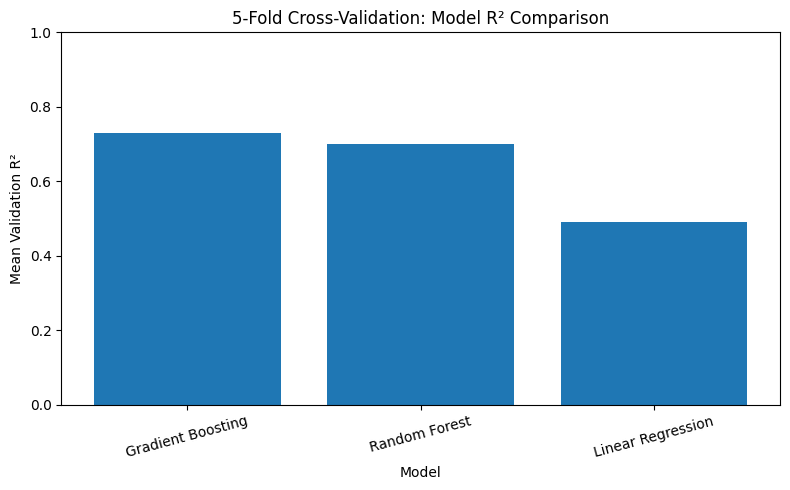

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    cv_comparison_df["Model"],
    cv_comparison_df["Validation R²"]
)

plt.ylabel("Mean Validation R²")
plt.xlabel("Model")
plt.title("5-Fold Cross-Validation: Model R² Comparison")

plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [54]:
# Train each model using the full training set

fitted_models = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

print("All three models trained successfully.")

All three models trained successfully.


In [55]:
# Generate predictions for the untouched test set

test_predictions = {}

for name, model in fitted_models.items():
    test_predictions[name] = model.predict(X_test)

print("Test-set predictions generated successfully.")

for name, predictions in test_predictions.items():
    print(f"{name}: {len(predictions)} predictions")

Test-set predictions generated successfully.
Linear Regression: 20 predictions
Random Forest: 20 predictions
Gradient Boosting: 20 predictions


In [56]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_results = []

for name, predictions in test_predictions.items():
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    test_results.append({
        "Model": name,
        "Test MAE": mae,
        "Test RMSE": rmse,
        "Test R²": r2
    })

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,Test MAE,Test RMSE,Test R²
0,Linear Regression,652602.093078,984887.143631,0.537266
1,Random Forest,375020.746296,684743.290445,0.776327
2,Gradient Boosting,403237.944212,676553.862920,0.781645


In [57]:
# Format the final test-set results

test_display = test_results_df.copy()

test_display["Test MAE"] = test_display["Test MAE"].apply(
    lambda x: f"${x:,.0f}"
)

test_display["Test RMSE"] = test_display["Test RMSE"].apply(
    lambda x: f"${x:,.0f}"
)

test_display["Test R²"] = test_display["Test R²"].round(4)

test_display

,Model,Test MAE,Test RMSE,Test R²
0,Linear Regression,"$652,602","$984,887",0.5373
1,Random Forest,"$375,021","$684,743",0.7763
2,Gradient Boosting,"$403,238","$676,554",0.7816


In [58]:
# Combine cross-validation and final test-set results

comparison_df = pd.DataFrame({
    "Model": list(cv_results.keys()),
    "CV MAE": [
        -cv_results[name]["test_MAE"].mean()
        for name in cv_results
    ],
    "CV RMSE": [
        -cv_results[name]["test_RMSE"].mean()
        for name in cv_results
    ],
    "CV R²": [
        cv_results[name]["test_R2"].mean()
        for name in cv_results
    ],
    "Test MAE": [
        test_results_df.loc[
            test_results_df["Model"] == name, "Test MAE"
        ].values[0]
        for name in cv_results
    ],
    "Test RMSE": [
        test_results_df.loc[
            test_results_df["Model"] == name, "Test RMSE"
        ].values[0]
        for name in cv_results
    ],
    "Test R²": [
        test_results_df.loc[
            test_results_df["Model"] == name, "Test R²"
        ].values[0]
        for name in cv_results
    ]
})

comparison_df

,Model,CV MAE,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,Linear Regression,648499.990712,930388.863923,0.490392,652602.093078,984887.143631,0.537266
1,Random Forest,395068.063041,767516.969532,0.701218,375020.746296,684743.290445,0.776327
2,Gradient Boosting,387967.889253,709919.295446,0.729659,403237.944212,676553.862920,0.781645


In [59]:
comparison_display = comparison_df.copy()

for column in ["CV MAE", "CV RMSE", "Test MAE", "Test RMSE"]:
    comparison_display[column] = comparison_display[column].apply(
        lambda x: f"${x:,.0f}"
    )

for column in ["CV R²", "Test R²"]:
    comparison_display[column] = comparison_display[column].round(4)

comparison_display

,Model,CV MAE,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²
0,Linear Regression,"$648,500","$930,389",0.4904,"$652,602","$984,887",0.5373
1,Random Forest,"$395,068","$767,517",0.7012,"$375,021","$684,743",0.7763
2,Gradient Boosting,"$387,968","$709,919",0.7297,"$403,238","$676,554",0.7816


In [60]:
comparison_analysis = comparison_df.copy()

comparison_analysis["MAE Difference"] = (
    comparison_analysis["Test MAE"] -
    comparison_analysis["CV MAE"]
)

comparison_analysis["RMSE Difference"] = (
    comparison_analysis["Test RMSE"] -
    comparison_analysis["CV RMSE"]
)

comparison_analysis["R² Difference"] = (
    comparison_analysis["Test R²"] -
    comparison_analysis["CV R²"]
)

comparison_analysis

,Model,CV MAE,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²,MAE Difference,RMSE Difference,R² Difference
0,Linear Regression,648499.990712,930388.863923,0.490392,652602.093078,984887.143631,0.537266,4102.102366,54498.279708,0.046874
1,Random Forest,395068.063041,767516.969532,0.701218,375020.746296,684743.290445,0.776327,-20047.316745,-82773.679087,0.075108
2,Gradient Boosting,387967.889253,709919.295446,0.729659,403237.944212,676553.862920,0.781645,15270.054959,-33365.432526,0.051986


In [63]:
cv_stability = []

for name, results in cv_results.items():
    cv_stability.append({
        "Model": name,
        "MAE Mean": -results["test_MAE"].mean(),
        "MAE Std": results["test_MAE"].std(),
        "RMSE Mean": -results["test_RMSE"].mean(),
        "RMSE Std": results["test_RMSE"].std(),
        "R² Mean": results["test_R2"].mean(),
        "R² Std": results["test_R2"].std()
    })

cv_stability_df = pd.DataFrame(cv_stability)

cv_stability_df



,Model,MAE Mean,MAE Std,RMSE Mean,RMSE Std,R² Mean,R² Std
0,Linear Regression,648499.990712,64609.574485,930388.863923,130435.331205,0.490392,0.181464
1,Random Forest,395068.063041,124446.095374,767516.969532,262392.152479,0.701218,0.069898
2,Gradient Boosting,387967.889253,68066.475636,709919.295446,180577.293861,0.729659,0.060929


In [64]:
cv_stability_display = cv_stability_df.copy()

for column in ["MAE Mean", "MAE Std", "RMSE Mean", "RMSE Std"]:
    cv_stability_display[column] = cv_stability_display[column].apply(
        lambda x: f"${x:,.0f}"
    )

for column in ["R² Mean", "R² Std"]:
    cv_stability_display[column] = cv_stability_display[column].round(4)

cv_stability_display

,Model,MAE Mean,MAE Std,RMSE Mean,RMSE Std,R² Mean,R² Std
0,Linear Regression,"$648,500","$64,610","$930,389","$130,435",0.4904,0.1815
1,Random Forest,"$395,068","$124,446","$767,517","$262,392",0.7012,0.0699
2,Gradient Boosting,"$387,968","$68,066","$709,919","$180,577",0.7297,0.0609


In [65]:
fold_r2_df = pd.DataFrame({
    name: results["test_R2"]
    for name, results in cv_results.items()
})

fold_r2_df.index = [f"Fold {i}" for i in range(1, 6)]

fold_r2_df

,Linear Regression,Random Forest,Gradient Boosting
Fold 1,0.176521,0.821344,0.748412
Fold 2,0.701205,0.662880,0.775681
Fold 3,0.480707,0.611640,0.613616
Fold 4,0.634053,0.720514,0.780902
Fold 5,0.459471,0.689715,0.729686


## Final Model Selection

The three regression models were evaluated using five-fold cross-validation and a separate 20% test set. The results showed that both Random Forest and Gradient Boosting substantially outperformed Linear Regression.

Linear Regression achieved a cross-validation R² of 0.4904 and a test R² of 0.5373, indicating that a simple linear relationship did not capture the variation in the housing prices sufficiently well.

Random Forest achieved a cross-validation R² of 0.7012 and a test R² of 0.7763. It also produced the lowest test MAE of AUD 375,021, indicating the smallest average absolute prediction error on the held-out test set.

Gradient Boosting achieved the highest cross-validation R² (0.7297) and the highest test R² (0.7816). It also produced the lowest cross-validation RMSE (AUD 709,919) and test RMSE (AUD 676,554). Its R² standard deviation across the five folds was 0.0609, indicating relatively stable validation performance.

Based on the combined cross-validation, test-set and stability results, Gradient Boosting was selected as the primary model for the decision-support prototype. Random Forest remained a competitive alternative because it achieved the lowest test MAE.

The original expectation that nonlinear tree-based models would outperform Linear Regression was supported by the evaluation results. However, all models showed some difference between training and validation performance, indicating that the models should still be interpreted cautiously given the small dataset and variation in property values.

## Part 4: Investigating Prediction Failures  

In [66]:
# Generate predictions from the selected Gradient Boosting model

final_model = fitted_models["Gradient Boosting"]

test_predictions_gb = final_model.predict(X_test)

print("Gradient Boosting test predictions generated:", len(test_predictions_gb))

# Create a table containing actual prices, predictions and errors

error_analysis_df = X_test.copy()

error_analysis_df["Actual Price"] = y_test.values
error_analysis_df["Predicted Price"] = test_predictions_gb

error_analysis_df["Error"] = (
    error_analysis_df["Actual Price"] -
    error_analysis_df["Predicted Price"]
)

error_analysis_df["Absolute Error"] = (
    error_analysis_df["Error"].abs()
)

error_analysis_df["Percentage Error"] = (
    error_analysis_df["Absolute Error"] /
    error_analysis_df["Actual Price"]
) * 100

error_analysis_df = error_analysis_df.sort_values(
    "Absolute Error",
    ascending=False
)

error_analysis_df.head(10)

top_5_errors = error_analysis_df.head(5).copy()

top_5_display = top_5_errors[
    [
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking",
        "listed_area_m2",
        "Actual Price",
        "Predicted Price",
        "Error",
        "Absolute Error",
        "Percentage Error"
    ]
].copy()

for column in [
    "Actual Price",
    "Predicted Price",
    "Error",
    "Absolute Error"
]:
    top_5_display[column] = top_5_display[column].apply(
        lambda x: f"${x:,.0f}"
    )

top_5_display["Percentage Error"] = (
    top_5_display["Percentage Error"].round(2).astype(str) + "%"
)

top_5_display

Gradient Boosting test predictions generated: 20


,suburb,property_type,bedrooms,bathrooms,parking,listed_area_m2,Actual Price,Predicted Price,Error,Absolute Error,Percentage Error
27,Manly,Unit,1,1.0,1.0,NaN,"$990,000","$2,971,575","$-1,981,575","$1,981,575",200.16%
30,Manly,Apartment,1,1.0,1.0,NaN,"$1,253,000","$2,733,202","$-1,480,202","$1,480,202",118.13%
31,Manly,Townhouse,3,2.0,2.0,NaN,"$6,300,000","$5,089,792","$1,210,208","$1,210,208",19.21%
95,Liverpool,Townhouse,4,3.0,1.0,241.0,"$962,000","$1,971,365","$-1,009,365","$1,009,365",104.92%
73,Liverpool,Unit,2,2.0,1.0,131.0,"$570,000","$210,026","$359,974","$359,974",63.15%


In [67]:
# Add property identifiers and original information to the error analysis

top_5_ids = top_5_errors.index

top_5_properties = ml_df.loc[
    top_5_ids,
    [
        "property_id",
        "property_address",
        "suburb",
        "postcode",
        "property_type",
        "sale_price_aud",
        "bedrooms",
        "bathrooms",
        "parking",
        "listed_area_m2",
        "sale_date",
        "source_page",
        "source_url"
    ]
].copy()

top_5_properties

,property_id,property_address,suburb,postcode,property_type,sale_price_aud,bedrooms,bathrooms,parking,listed_area_m2,sale_date,source_page,source_url
27,M028,"4/51C Kangaroo Street, Manly, NSW 2095",Manly,2095,Unit,990000,1,1.0,1.0,NaN,2026-06-26,Manly sold listings page 2,"https://www.realestate.com.au/sold/in-manly,%2..."
30,M031,"12/14 Malvern Avenue, Manly, NSW 2095",Manly,2095,Apartment,1253000,1,1.0,1.0,NaN,2026-06-13,Manly sold listings page 2,"https://www.realestate.com.au/sold/in-manly,%2..."
31,M032,"5/19a Addison Road, Manly, NSW 2095",Manly,2095,Townhouse,6300000,3,2.0,2.0,NaN,2026-06-12,Manly sold listings page 2,"https://www.realestate.com.au/sold/in-manly,%2..."
95,L029,"1/10 Tobruk Avenue, Liverpool, NSW 2170",Liverpool,2170,Townhouse,962000,4,3.0,1.0,241.0,2026-08-10,Liverpool sold listings page 2,https://www.realestate.com.au/sold/in-liverpoo...
73,L007,"505/17 Shepherd Street, Liverpool, NSW 2170",Liverpool,2170,Unit,570000,2,2.0,1.0,131.0,2026-09-11,Liverpool sold listings page 1,https://www.realestate.com.au/sold/in-liverpoo...


In [68]:
top_5_properties["Predicted Price"] = test_predictions_gb[
    [
        list(X_test.index).index(i)
        for i in top_5_ids
    ]
]

top_5_properties["Error"] = (
    top_5_properties["sale_price_aud"] -
    top_5_properties["Predicted Price"]
)

top_5_properties["Absolute Error"] = (
    top_5_properties["Error"].abs()
)

top_5_properties["Percentage Error"] = (
    top_5_properties["Absolute Error"] /
    top_5_properties["sale_price_aud"]
) * 100

top_5_properties = top_5_properties.sort_values(
    "Absolute Error",
    ascending=False
)

top_5_properties

,property_id,property_address,suburb,postcode,property_type,sale_price_aud,bedrooms,bathrooms,parking,listed_area_m2,sale_date,source_page,source_url,Predicted Price,Error,Absolute Error,Percentage Error
27,M028,"4/51C Kangaroo Street, Manly, NSW 2095",Manly,2095,Unit,990000,1,1.0,1.0,NaN,2026-06-26,Manly sold listings page 2,"https://www.realestate.com.au/sold/in-manly,%2...",2.971575e+06,-1.981575e+06,1.981575e+06,200.159130
30,M031,"12/14 Malvern Avenue, Manly, NSW 2095",Manly,2095,Apartment,1253000,1,1.0,1.0,NaN,2026-06-13,Manly sold listings page 2,"https://www.realestate.com.au/sold/in-manly,%2...",2.733202e+06,-1.480202e+06,1.480202e+06,118.132648
31,M032,"5/19a Addison Road, Manly, NSW 2095",Manly,2095,Townhouse,6300000,3,2.0,2.0,NaN,2026-06-12,Manly sold listings page 2,"https://www.realestate.com.au/sold/in-manly,%2...",5.089792e+06,1.210208e+06,1.210208e+06,19.209646
95,L029,"1/10 Tobruk Avenue, Liverpool, NSW 2170",Liverpool,2170,Townhouse,962000,4,3.0,1.0,241.0,2026-08-10,Liverpool sold listings page 2,https://www.realestate.com.au/sold/in-liverpoo...,1.971365e+06,-1.009365e+06,1.009365e+06,104.923597
73,L007,"505/17 Shepherd Street, Liverpool, NSW 2170",Liverpool,2170,Unit,570000,2,2.0,1.0,131.0,2026-09-11,Liverpool sold listings page 1,https://www.realestate.com.au/sold/in-liverpoo...,2.100259e+05,3.599741e+05,3.599741e+05,63.153355


In [69]:
investigation_table = top_5_properties[
    [
        "property_id",
        "property_address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking",
        "listed_area_m2",
        "sale_date",
        "sale_price_aud",
        "Predicted Price",
        "Absolute Error",
        "Percentage Error"
    ]
].copy()

investigation_table

,property_id,property_address,suburb,property_type,bedrooms,bathrooms,parking,listed_area_m2,sale_date,sale_price_aud,Predicted Price,Absolute Error,Percentage Error
27,M028,"4/51C Kangaroo Street, Manly, NSW 2095",Manly,Unit,1,1.0,1.0,NaN,2026-06-26,990000,2.971575e+06,1.981575e+06,200.159130
30,M031,"12/14 Malvern Avenue, Manly, NSW 2095",Manly,Apartment,1,1.0,1.0,NaN,2026-06-13,1253000,2.733202e+06,1.480202e+06,118.132648
31,M032,"5/19a Addison Road, Manly, NSW 2095",Manly,Townhouse,3,2.0,2.0,NaN,2026-06-12,6300000,5.089792e+06,1.210208e+06,19.209646
95,L029,"1/10 Tobruk Avenue, Liverpool, NSW 2170",Liverpool,Townhouse,4,3.0,1.0,241.0,2026-08-10,962000,1.971365e+06,1.009365e+06,104.923597
73,L007,"505/17 Shepherd Street, Liverpool, NSW 2170",Liverpool,Unit,2,2.0,1.0,131.0,2026-09-11,570000,2.100259e+05,3.599741e+05,63.153355


In [70]:
# Compare each high-error property with other properties
# in the same suburb

for idx in top_5_ids:
    row = ml_df.loc[idx]

    print("=" * 80)
    print(f"Property: {row['property_id']} - {row['property_address']}")
    print(f"Suburb: {row['suburb']}")
    print(f"Actual sale price: ${row['sale_price_aud']:,.0f}")

    suburb_data = ml_df[ml_df["suburb"] == row["suburb"]]

    print("\nSuburb price statistics:")
    print(f"Median: ${suburb_data['sale_price_aud'].median():,.0f}")
    print(f"Mean:   ${suburb_data['sale_price_aud'].mean():,.0f}")

Property: M028 - 4/51C Kangaroo Street, Manly, NSW 2095
Suburb: Manly
Actual sale price: $990,000

Suburb price statistics:
Median: $1,962,500
Mean:   $2,629,869
Property: M031 - 12/14 Malvern Avenue, Manly, NSW 2095
Suburb: Manly
Actual sale price: $1,253,000

Suburb price statistics:
Median: $1,962,500
Mean:   $2,629,869
Property: M032 - 5/19a Addison Road, Manly, NSW 2095
Suburb: Manly
Actual sale price: $6,300,000

Suburb price statistics:
Median: $1,962,500
Mean:   $2,629,869
Property: L029 - 1/10 Tobruk Avenue, Liverpool, NSW 2170
Suburb: Liverpool
Actual sale price: $962,000

Suburb price statistics:
Median: $550,000
Mean:   $646,273
Property: L007 - 505/17 Shepherd Street, Liverpool, NSW 2170
Suburb: Liverpool
Actual sale price: $570,000

Suburb price statistics:
Median: $550,000
Mean:   $646,273


In [71]:
# Find properties with similar basic characteristics

for idx in top_5_ids:
    row = ml_df.loc[idx]

    comparable = ml_df[
        (ml_df["suburb"] == row["suburb"]) &
        (ml_df["property_type"] == row["property_type"]) &
        (ml_df["bedrooms"] == row["bedrooms"])
    ].copy()

    comparable = comparable.sort_values("sale_price_aud")

    print("=" * 100)
    print(f"Target: {row['property_id']} - {row['property_address']}")
    print(f"Characteristics: {row['suburb']}, {row['property_type']}, "
          f"{row['bedrooms']} bedrooms")

    print("\nComparable properties:")
    print(
        comparable[
            [
                "property_id",
                "property_address",
                "sale_price_aud",
                "bathrooms",
                "parking",
                "listed_area_m2",
                "sale_date"
            ]
        ].to_string(index=False)
    )

Target: M028 - 4/51C Kangaroo Street, Manly, NSW 2095
Characteristics: Manly, Unit, 1 bedrooms

Comparable properties:
property_id                       property_address  sale_price_aud  bathrooms  parking  listed_area_m2  sale_date
       M028 4/51C Kangaroo Street, Manly, NSW 2095          990000        1.0      1.0             NaN 2026-06-26
       M012  16/51 Pittwater Road, Manly, NSW 2095         1130000        1.0      1.0             NaN 2026-08-14
Target: M031 - 12/14 Malvern Avenue, Manly, NSW 2095
Characteristics: Manly, Apartment, 1 bedrooms

Comparable properties:
property_id                          property_address  sale_price_aud  bathrooms  parking  listed_area_m2  sale_date
       M017 308B/9-15 Central Avenue, Manly, NSW 2095          747000        NaN      NaN            50.0 2026-07-24
       M010      1/22 Eurobin Avenue, Manly, NSW 2095          790000        1.0      1.0             NaN 2026-08-20
       M002         4/3 Cliff Street, Manly, NSW 2095          84

In [72]:
# Calculate where each high-error property's price sits
# among properties with the same suburb, type and bedroom count

comparison_summary = []

for idx in top_5_ids:
    row = ml_df.loc[idx]

    comparable = ml_df[
        (ml_df["suburb"] == row["suburb"]) &
        (ml_df["property_type"] == row["property_type"]) &
        (ml_df["bedrooms"] == row["bedrooms"])
    ]

    comparison_summary.append({
        "Property ID": row["property_id"],
        "Address": row["property_address"],
        "Actual Price": row["sale_price_aud"],
        "Comparable Count": len(comparable),
        "Comparable Median": comparable["sale_price_aud"].median(),
        "Difference from Comparable Median":
            row["sale_price_aud"] - comparable["sale_price_aud"].median()
    })

comparison_summary_df = pd.DataFrame(comparison_summary)

comparison_summary_df

,Property ID,Address,Actual Price,Comparable Count,Comparable Median,Difference from Comparable Median
0,M028,"4/51C Kangaroo Street, Manly, NSW 2095",990000,2,1060000.0,-70000.0
1,M031,"12/14 Malvern Avenue, Manly, NSW 2095",1253000,5,840000.0,413000.0
2,M032,"5/19a Addison Road, Manly, NSW 2095",6300000,1,6300000.0,0.0
3,L029,"1/10 Tobruk Avenue, Liverpool, NSW 2170",962000,1,962000.0,0.0
4,L007,"505/17 Shepherd Street, Liverpool, NSW 2170",570000,8,560000.0,10000.0


In [73]:
# Examine missing-information patterns for the five largest errors

missing_analysis = top_5_properties[
    [
        "property_id",
        "property_address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking",
        "listed_area_m2",
        "sale_price_aud",
        "Predicted Price",
        "Absolute Error",
        "Percentage Error"
    ]
].copy()

missing_analysis["Area Missing"] = (
    missing_analysis["listed_area_m2"].isna()
)

missing_analysis["Bathrooms Missing"] = (
    missing_analysis["bathrooms"].isna()
)

missing_analysis["Parking Missing"] = (
    missing_analysis["parking"].isna()
)

missing_analysis[
    [
        "property_id",
        "Area Missing",
        "Bathrooms Missing",
        "Parking Missing"
    ]
]

,property_id,Area Missing,Bathrooms Missing,Parking Missing
27,M028,True,False,False
30,M031,True,False,False
31,M032,True,False,False
95,L029,False,False,False
73,L007,False,False,False


In [74]:
# Compare prediction errors for properties with and without area information

ml_df["area_missing"] = ml_df["listed_area_m2"].isna()

area_error_comparison = error_analysis_df.copy()

area_error_comparison["area_missing"] = (
    area_error_comparison["listed_area_m2"].isna()
)

area_error_summary = (
    area_error_comparison
    .groupby("area_missing")["Absolute Error"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

area_error_summary

,area_missing,count,mean,median
0,False,10,242681.415963,109098.229431
1,True,10,563794.472461,195396.886917


In [75]:
# Compare prediction errors across property types in the test set

property_type_error_summary = (
    error_analysis_df
    .groupby("property_type")["Absolute Error"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

property_type_error_summary

,property_type,count,mean,median
0,Townhouse,3,787137.275972,1.009365e+06
1,Unit,5,553941.025879,3.100042e+05
2,House,1,269072.430492,2.690724e+05
3,Apartment,11,242233.590585,1.089448e+05


In [76]:
# Final summary of the five largest prediction errors

part4_summary = top_5_properties[
    [
        "property_id",
        "property_address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "parking",
        "listed_area_m2",
        "sale_date",
        "sale_price_aud",
        "Predicted Price",
        "Absolute Error",
        "Percentage Error"
    ]
].copy()

part4_summary

,property_id,property_address,suburb,property_type,bedrooms,bathrooms,parking,listed_area_m2,sale_date,sale_price_aud,Predicted Price,Absolute Error,Percentage Error
27,M028,"4/51C Kangaroo Street, Manly, NSW 2095",Manly,Unit,1,1.0,1.0,NaN,2026-06-26,990000,2.971575e+06,1.981575e+06,200.159130
30,M031,"12/14 Malvern Avenue, Manly, NSW 2095",Manly,Apartment,1,1.0,1.0,NaN,2026-06-13,1253000,2.733202e+06,1.480202e+06,118.132648
31,M032,"5/19a Addison Road, Manly, NSW 2095",Manly,Townhouse,3,2.0,2.0,NaN,2026-06-12,6300000,5.089792e+06,1.210208e+06,19.209646
95,L029,"1/10 Tobruk Avenue, Liverpool, NSW 2170",Liverpool,Townhouse,4,3.0,1.0,241.0,2026-08-10,962000,1.971365e+06,1.009365e+06,104.923597
73,L007,"505/17 Shepherd Street, Liverpool, NSW 2170",Liverpool,Unit,2,2.0,1.0,131.0,2026-09-11,570000,2.100259e+05,3.599741e+05,63.153355


In [77]:
# Classify the direction of each large prediction error

part4_summary["Prediction Direction"] = part4_summary.apply(
    lambda row: "Overprediction"
    if row["Predicted Price"] > row["sale_price_aud"]
    else "Underprediction",
    axis=1
)

part4_summary[
    [
        "property_id",
        "sale_price_aud",
        "Predicted Price",
        "Absolute Error",
        "Percentage Error",
        "Prediction Direction"
    ]
]

,property_id,sale_price_aud,Predicted Price,Absolute Error,Percentage Error,Prediction Direction
27,M028,990000,2.971575e+06,1.981575e+06,200.159130,Overprediction
30,M031,1253000,2.733202e+06,1.480202e+06,118.132648,Overprediction
31,M032,6300000,5.089792e+06,1.210208e+06,19.209646,Underprediction
95,L029,962000,1.971365e+06,1.009365e+06,104.923597,Overprediction
73,L007,570000,2.100259e+05,3.599741e+05,63.153355,Underprediction


## Part 4: Investigation of the Largest Prediction Errors

The five properties with the largest absolute prediction errors were investigated to understand situations in which the selected Gradient Boosting model struggled.

The largest error occurred for M028 (4/51C Kangaroo Street, Manly), where the actual sale price was AUD 990,000 while the predicted price was approximately AUD 2.97 million. This was an overprediction of approximately AUD 1.98 million. The property had missing listed-area information. However, its actual price was close to the median of the available one-bedroom Manly unit comparables in the dataset, suggesting that the large error was not simply caused by an unusually low sale price.

M031 (12/14 Malvern Avenue, Manly) was also substantially overpredicted. Its actual sale price was AUD 1.253 million compared with a predicted price of approximately AUD 2.73 million. The actual price was above the median of the available one-bedroom Manly apartment comparables, but the model prediction was substantially higher than the observed comparable prices.

M032 (5/19a Addison Road, Manly) was underpredicted by approximately AUD 1.21 million. The actual sale price was AUD 6.3 million, while the model predicted approximately AUD 5.09 million. There was only one property in the dataset matching its suburb, property type and bedroom count, so the available dataset provides limited comparable evidence for this property.

L029 (1/10 Tobruk Avenue, Liverpool) was overpredicted by approximately AUD 1.01 million. Its actual sale price was AUD 962,000 compared with a prediction of approximately AUD 1.97 million. This property was a four-bedroom townhouse with three bathrooms and 241 m² of listed area. There was only one matching Liverpool four-bedroom townhouse in the dataset, limiting the ability to investigate its price using comparable observations.

L007 (505/17 Shepherd Street, Liverpool) was underpredicted by approximately AUD 360,000. Its actual sale price was AUD 570,000, while the predicted price was approximately AUD 210,000. The actual price was close to the median of the available two-bedroom Liverpool unit comparables, showing that even a property with a relatively ordinary comparable-market position could receive a large prediction error.

### Missing Information and Prediction Errors

The test-set analysis also showed that properties without listed-area information had higher prediction errors. Properties with missing area information had a mean absolute error of approximately AUD 563,794, compared with approximately AUD 242,681 for properties where area information was available. The median absolute errors were approximately AUD 195,397 and AUD 109,098 respectively.

This does not establish that missing area directly caused the larger errors, particularly because the test set contains only 20 properties. However, it indicates that incomplete property information is an important limitation of the current model.

### Property Type and Model Difficulty

Prediction errors also varied across property types. Townhouses had the highest mean absolute error in the test set at approximately AUD 787,137, followed by units at approximately AUD 553,941. Apartments had a lower mean absolute error of approximately AUD 242,234. However, the test-set sample sizes were small, particularly for houses and townhouses, so these differences should not be generalised to the wider housing market.

### Modelling Limitations

The large errors demonstrate that the available features do not capture all factors that influence individual property prices. The dataset contains basic structural and location information, but information such as detailed property condition, renovation quality, views, floor level, exact proximity to amenities or transport, land characteristics, development potential and other property-specific attributes may affect sale prices.

Predictions should therefore be interpreted cautiously for properties with unusual characteristics, very high sale prices, limited comparable observations, or substantial missing information.

Overall, the error analysis shows that the model can explain a substantial proportion of price variation while still producing large errors for individual properties. This reinforces the role of the system as a decision-support tool rather than a replacement for detailed property valuation and professional judgement.

## Part 5: Final Deployment and Reflection

In [78]:
# Confirm the selected final model

final_model = pipelines["Gradient Boosting"]

print("Final model:")
print(final_model)

print("\nModel type:")
print(type(final_model.named_steps["model"]).__name__)

Final model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['bedrooms', 'bathrooms',
                                                   'parking', 'listed_area_m2',
                                                   'sale_year', 'sale_month',
                                                   'sale_quarter',
                                                   'area_available']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                      

In [79]:
# Fit the final Gradient Boosting model on the training data

final_model.fit(X_train, y_train)

print("Final Gradient Boosting model fitted successfully.")

Final Gradient Boosting model fitted successfully.


In [80]:
# Verify that the final model is fitted

print("Training samples used:", len(X_train))
print("Predictor columns used:")
print(X_train.columns.tolist())

Training samples used: 80
Predictor columns used:
['suburb', 'property_type', 'bedrooms', 'bathrooms', 'parking', 'listed_area_m2', 'sale_year', 'sale_month', 'sale_quarter', 'area_available']


In [81]:
# Save the model

import joblib

model_path = "final_gradient_boosting_model.pkl"

joblib.dump(final_model, model_path)

print(f"Model saved successfully as: {model_path}")

Model saved successfully as: final_gradient_boosting_model.pkl


In [82]:
import os

print("File exists:", os.path.exists(model_path))
print("File size:", round(os.path.getsize(model_path) / 1024, 2), "KB")

File exists: True
File size: 155.81 KB


In [83]:
from google.colab import files

files.download("final_gradient_boosting_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [84]:
import sys
import sklearn
import numpy
import pandas
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Joblib:", joblib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
scikit-learn: 1.6.1
NumPy: 2.1.3
Pandas: 2.2.3
Joblib: 1.6.0
